/opt/conda/lib/python3.8/site-packages/IPython/core/pylabtools.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


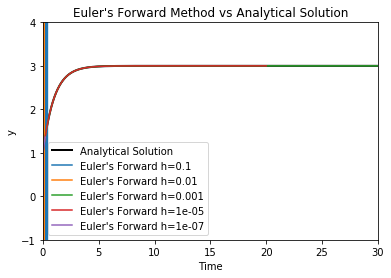

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

def analytical(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

def euler_forward(h, t_start, t_end, y0):
    t = np.arange(t_start, t_end + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(1, len(t)):
        y[i] = y[i-1] + h * f(t[i-1], y[i-1])
        if abs(y[i]) > 1e10:
            y[i:] = np.nan
            break
    return t, y

#parameters 
t_start = 0
t_end   = 30
y0      = 0.0
h_values = [0.1, 0.01, 0.001, 0.00001, 0.0000001]

plt.figure()

t_exact = np.linspace(t_start, t_end, 100000)
plt.plot(t_exact, analytical(t_exact), 'k-', linewidth=2, label='Analytical Solution')

for h in h_values:
    effective_end = min(t_end, h * 2_000_000)
    t, y = euler_forward(h, t_start, effective_end, y0)
    plt.plot(t, y, label=f"Euler's Forward h={h}")

plt.ylim(-1, 4)
plt.xlim(0, 30)
plt.xlabel('Time')
plt.ylabel('y')
plt.title("Euler's Forward Method vs Analytical Solution")
plt.legend()
plt.show()